# Q-ACCeSS-T Phase 1 High-Bitrate FLV PCAP Analysis

This notebook compares **baseline (4D-MAP)** and **Q-ACCeSS-T** using **pcap-derived throughput** on the client (h1). The input FLV is high-bitrate (~53 Mbps, ~200 s) to stress multipath capacity more than a low-bitrate source.

The metric is **wire-level throughput** (bytes on the capture interface × 8 / time). It includes QUIC/UDP headers and possible retransmissions; it is **not** application goodput.

**Topology (Fig.7):**
- Path A: `h1-eth0` / `h2-eth0` (10.0.1.0/24), static TCLink ~20 Mbps
- Path B: `h1-eth1` / `h2-eth1` (10.0.2.0/24); dynamic TBF on **h2-eth1** (server egress)

**Configured Path B caps (tc profile, design times 0 / 50 / 100 s from tc script start):**
- 0–50 s: 20 Mbps
- 50–100 s: 30 Mbps
- 100–200 s: 10 Mbps

Vertical lines at 50 s and 100 s in plots are **configured profile markers**, not necessarily aligned to pcap second zero (first QUIC packet). Interpret **total** together with **Path A / Path B**, especially **Path B downlink** (h2→h1).

Phase 1 only: **baseline vs qaccess_t** (no Phase 2 static/dynamic/worker).

In [1]:
import importlib.util
import math
import os
import shutil
import subprocess
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_PACKAGES = ["pandas", "matplotlib", "numpy"]
_missing = [p for p in _PACKAGES if importlib.util.find_spec(p) is None]
if _missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--disable-pip-version-check", "--no-input", *_missing],
        timeout=600,
    )

try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except (ImportError, AttributeError):
    os.environ.setdefault("MPLBACKEND", "Agg")

plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 11})


def find_repo() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "scripts" / "analyze" / "parse_logs.py").is_file():
            return p
    return cwd


REPO = find_repo()
print("REPO =", REPO)

REPO = /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment


In [2]:
SESSION = REPO / "logs_exp" / "session_qaccess_t_20260527_011113"

RUN_DIR_CANDIDATES = {
    "baseline": ["fig7_um_baseline", "fig7_baseline"],
    "qaccess_t": ["fig7_um_qaccess_t", "fig7_qaccess_t"],
}


def resolve_run_dir(session: Path, label: str) -> Path:
    for name in RUN_DIR_CANDIDATES[label]:
        p = session / name
        if p.is_dir():
            return p
    raise FileNotFoundError(f"No run dir for {label} under {session}: {RUN_DIR_CANDIDATES[label]}")


RUNS = {lab: resolve_run_dir(SESSION, lab) for lab in RUN_DIR_CANDIDATES}

OUT_DIR = SESSION / "compare_phase1_high_bitrate"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SECOND_MAX = 220
FILTER_ALL = "udp"
FILTER_DOWN_A = "ip.src == 10.0.1.2 && ip.dst == 10.0.1.1 && udp"
FILTER_DOWN_B = "ip.src == 10.0.2.2 && ip.dst == 10.0.2.1 && udp"

WINDOWS = [
    ("0-50", 0, 50),
    ("50-60", 50, 60),
    ("50-100", 50, 100),
    ("100-110", 100, 110),
    ("100-150", 100, 150),
    ("150-200", 150, 200),
    ("full", 0, 201),
]

PATH_B_CAP_STEPS = [(0, 20), (50, 30), (100, 10)]

assert shutil.which("tshark"), "tshark not on PATH (install Wireshark)"
print("SESSION =", SESSION.resolve())
for lab, rd in RUNS.items():
    print(f"  [{lab}] -> {rd.name}")

SESSION = /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_qaccess_t_20260527_011113
  [baseline] -> fig7_baseline
  [qaccess_t] -> fig7_qaccess_t


In [3]:
print("SESSION:", SESSION.resolve())
print()

for lab, run_dir in RUNS.items():
    print(f"=== [{lab}] {run_dir.name} ===")
    print("  run_dir:", run_dir.resolve())
    pcaps = sorted((run_dir / "pcaps").glob("path*.pcap")) if (run_dir / "pcaps").is_dir() else []
    for p in pcaps:
        print(f"  pcap: {p.name} ({p.stat().st_size / 1e6:.1f} MB)")
    tc_logs = sorted((run_dir / "logs").glob("tc_bw_*.log")) if (run_dir / "logs").is_dir() else []
    if tc_logs:
        for tl in tc_logs:
            print(f"  tc_bw log: {tl.name}")
            lines = tl.read_text(encoding="utf-8", errors="replace").splitlines()[:60]
            for ln in lines:
                print("   ", ln)
    else:
        print("  tc_bw log: (none)")
    outs = sorted(run_dir.glob("output_*.flv"))
    for o in outs:
        print(f"  output FLV: {o.name} ({o.stat().st_size / 1e6:.1f} MB)")
    print()

any_tc = any(
    list((rd / "logs").glob("tc_bw_*.log"))
    for rd in RUNS.values()
    if (rd / "logs").is_dir()
)
if not any_tc:
    print(
        "tc_bw log not found. Re-run with SAVE_LOGS=1 if bandwidth-profile verification is needed."
    )

SESSION: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_qaccess_t_20260527_011113

=== [baseline] fig7_baseline ===
  run_dir: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_qaccess_t_20260527_011113/fig7_baseline
  pcap: pathA_h1_20260527_011113.pcap (644.7 MB)
  pcap: pathB_h1_20260527_011113.pcap (15.0 MB)
  tc_bw log: (none)
  output FLV: output_20260527_011113.flv (93.3 MB)

=== [qaccess_t] fig7_qaccess_t ===
  run_dir: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_qaccess_t_20260527_011113/fig7_qaccess_t
  pcap: pathA_h1_20260527_011504.pcap (634.2 MB)
  pcap: pathB_h1_20260527_011504.pcap (52.5 MB)
  tc_bw log: (none)
  output FLV: output_20260527_011504.flv (111.2 MB)

tc_bw log not found. Re-run with SAVE_LOGS=1 if bandwidth-profile verification is needed.


In [4]:
def find_path_pcaps(run_dir: Path) -> tuple[Path, Path]:
    pcaps = sorted((run_dir / "pcaps").glob("path*.pcap"))
    pcap_a = next(p for p in pcaps if "pathA" in p.name)
    pcap_b = next(p for p in pcaps if "pathB" in p.name)
    return pcap_a, pcap_b


def read_pcap_rows(pcap: Path, display_filter: str) -> pd.DataFrame:
    """Return epoch (s) and frame_len per packet. Uses frame.time_epoch."""
    cmd = [
        "tshark", "-r", str(pcap), "-Y", display_filter,
        "-T", "fields", "-E", "separator=\t",
        "-e", "frame.time_epoch", "-e", "frame.len",
    ]
    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if proc.returncode != 0:
        raise RuntimeError(proc.stderr.strip() or f"tshark failed: {pcap}")
    rows = []
    for line in proc.stdout.splitlines():
        parts = line.strip().split("\t")
        if len(parts) < 2:
            continue
        try:
            rows.append({"epoch": float(parts[0]), "frame_len": int(parts[1])})
        except ValueError:
            continue
    return pd.DataFrame(rows)


def aggregate_mbps(df: pd.DataFrame, global_t0: float, last_second: int) -> pd.Series:
    bins = defaultdict(int)
    if df.empty:
        return pd.Series(0.0, index=range(0, last_second + 1), dtype="float64")
    for _, row in df.iterrows():
        si = int(math.floor(row["epoch"] - global_t0))
        if 0 <= si <= last_second:
            bins[si] += int(row["frame_len"])
    return pd.Series(
        [bins.get(s, 0) * 8 / 1_000_000 for s in range(0, last_second + 1)],
        dtype="float64",
    )


print("Pcap reader ready (frame.time_epoch + per-run global_t0).")

Pcap reader ready (frame.time_epoch + per-run global_t0).


In [5]:
def build_run_timeseries(label: str, run_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, float]:
    pcap_a, pcap_b = find_path_pcaps(run_dir)
    print(f"[{label}] reading pcaps ...", flush=True)

    df_a_all = read_pcap_rows(pcap_a, FILTER_ALL)
    df_b_all = read_pcap_rows(pcap_b, FILTER_ALL)
    df_a_dn = read_pcap_rows(pcap_a, FILTER_DOWN_A)
    df_b_dn = read_pcap_rows(pcap_b, FILTER_DOWN_B)

    epochs = []
    for d in (df_a_all, df_b_all, df_a_dn, df_b_dn):
        if not d.empty:
            epochs.append(d["epoch"].min())
    if not epochs:
        raise RuntimeError(f"no packets in {run_dir}")
    global_t0 = float(min(epochs))

    last_second = int(
        max(
            SECOND_MAX,
            max((int(math.floor(e - global_t0)) for d in (df_a_all, df_b_all) if not d.empty for e in d["epoch"]), default=0),
        )
    )

    s_a = aggregate_mbps(df_a_all, global_t0, last_second)
    s_b = aggregate_mbps(df_b_all, global_t0, last_second)
    s_a_dn = aggregate_mbps(df_a_dn, global_t0, last_second)
    s_b_dn = aggregate_mbps(df_b_dn, global_t0, last_second)

    df_all = pd.DataFrame({
        "second": range(0, last_second + 1),
        "pathA_mbps": s_a.values,
        "pathB_mbps": s_b.values,
    })
    df_all["total_mbps"] = df_all["pathA_mbps"] + df_all["pathB_mbps"]

    df_dn = pd.DataFrame({
        "second": range(0, last_second + 1),
        "pathA_downlink_mbps": s_a_dn.values,
        "pathB_downlink_mbps": s_b_dn.values,
    })
    df_dn["total_downlink_mbps"] = df_dn["pathA_downlink_mbps"] + df_dn["pathB_downlink_mbps"]

    print(f"  global_t0 epoch={global_t0:.3f}  last_second={last_second}  packets A={len(df_a_all)} B={len(df_b_all)}")
    return df_all, df_dn, global_t0


timeseries_all = {}
timeseries_dn = {}
global_t0s = {}

for lab, run_dir in RUNS.items():
    df_all, df_dn, t0 = build_run_timeseries(lab, run_dir)
    timeseries_all[lab] = df_all
    timeseries_dn[lab] = df_dn
    global_t0s[lab] = t0
    df_all.to_csv(OUT_DIR / f"throughput_timeseries_{lab}.csv", index=False)
    df_dn.to_csv(OUT_DIR / f"throughput_downlink_timeseries_{lab}.csv", index=False)
    print(f"  wrote throughput_timeseries_{lab}.csv")
    print(f"  wrote throughput_downlink_timeseries_{lab}.csv")

df_baseline = timeseries_all["baseline"]
df_qaccess = timeseries_all["qaccess_t"]
df_baseline_dn = timeseries_dn["baseline"]
df_qaccess_dn = timeseries_dn["qaccess_t"]

[baseline] reading pcaps ...
  global_t0 epoch=1779844275.354  last_second=225  packets A=539464 B=154784
  wrote throughput_timeseries_baseline.csv
  wrote throughput_downlink_timeseries_baseline.csv
[qaccess_t] reading pcaps ...
  global_t0 epoch=1779844505.508  last_second=225  packets A=559165 B=163203
  wrote throughput_timeseries_qaccess_t.csv
  wrote throughput_downlink_timeseries_qaccess_t.csv


In [6]:
def mean_in_window(df: pd.DataFrame, col: str, lo: int, hi: int) -> float:
    w = df[(df["second"] >= lo) & (df["second"] < hi)]
    return float(w[col].mean()) if len(w) else float("nan")


rows = []
for name, lo, hi in WINDOWS:
    b_tot = mean_in_window(df_baseline, "total_mbps", lo, hi)
    q_tot = mean_in_window(df_qaccess, "total_mbps", lo, hi)
    b_dn = mean_in_window(df_baseline_dn, "total_downlink_mbps", lo, hi)
    q_dn = mean_in_window(df_qaccess_dn, "total_downlink_mbps", lo, hi)
    imp = (q_tot - b_tot) / b_tot * 100.0 if b_tot > 0 else float("nan")
    imp_dn = (q_dn - b_dn) / b_dn * 100.0 if b_dn > 0 else float("nan")
    rows.append({
        "window": name,
        "baseline_total_mbps": round(b_tot, 3),
        "qaccess_t_total_mbps": round(q_tot, 3),
        "improvement_pct": round(imp, 2),
        "baseline_total_downlink_mbps": round(b_dn, 3),
        "qaccess_t_total_downlink_mbps": round(q_dn, 3),
        "downlink_improvement_pct": round(imp_dn, 2),
    })

df_windows = pd.DataFrame(rows)
csv_windows = OUT_DIR / "phase1_high_bitrate_window_summary.csv"
df_windows.to_csv(csv_windows, index=False)
print("Window summary (mean throughput, Mbps):")
display(df_windows)
print("Saved", csv_windows)

Window summary (mean throughput, Mbps):


,window,baseline_total_mbps,qaccess_t_total_mbps,improvement_pct,baseline_total_downlink_mbps,qaccess_t_total_downlink_mbps,downlink_improvement_pct
0,0-50,17.411,19.966,14.67,1.675,3.412,103.64
1,50-60,22.677,24.873,9.68,2.696,4.873,80.74
2,50-100,23.141,25.170,8.77,3.181,5.172,62.57
3,100-110,23.884,25.434,6.49,3.886,5.445,40.12
4,100-150,24.380,24.642,1.08,4.381,4.647,6.08
5,150-200,25.547,24.776,-3.02,5.553,4.778,-13.96
6,full,22.633,23.649,4.49,3.706,4.509,21.65


Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_qaccess_t_20260527_011113/compare_phase1_high_bitrate/phase1_high_bitrate_window_summary.csv


In [7]:
pair_rows = []
for _, r in df_windows.iterrows():
    pair_rows.append({
        "window": r["window"],
        "baseline_mbps": r["baseline_total_mbps"],
        "qaccess_t_mbps": r["qaccess_t_total_mbps"],
        "improvement_pct": r["improvement_pct"],
        "baseline_downlink_mbps": r["baseline_total_downlink_mbps"],
        "qaccess_t_downlink_mbps": r["qaccess_t_total_downlink_mbps"],
        "downlink_improvement_pct": r["downlink_improvement_pct"],
    })

df_pair = pd.DataFrame(pair_rows)
csv_pair = OUT_DIR / "phase1_high_bitrate_pairwise_improvement.csv"
df_pair.to_csv(csv_pair, index=False)
print("Pairwise: baseline -> qaccess_t")
display(df_pair)
print("Saved", csv_pair)

Pairwise: baseline -> qaccess_t


,window,baseline_mbps,qaccess_t_mbps,improvement_pct,baseline_downlink_mbps,qaccess_t_downlink_mbps,downlink_improvement_pct
0,0-50,17.411,19.966,14.67,1.675,3.412,103.64
1,50-60,22.677,24.873,9.68,2.696,4.873,80.74
2,50-100,23.141,25.170,8.77,3.181,5.172,62.57
3,100-110,23.884,25.434,6.49,3.886,5.445,40.12
4,100-150,24.380,24.642,1.08,4.381,4.647,6.08
5,150-200,25.547,24.776,-3.02,5.553,4.778,-13.96
6,full,22.633,23.649,4.49,3.706,4.509,21.65


Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_qaccess_t_20260527_011113/compare_phase1_high_bitrate/phase1_high_bitrate_pairwise_improvement.csv


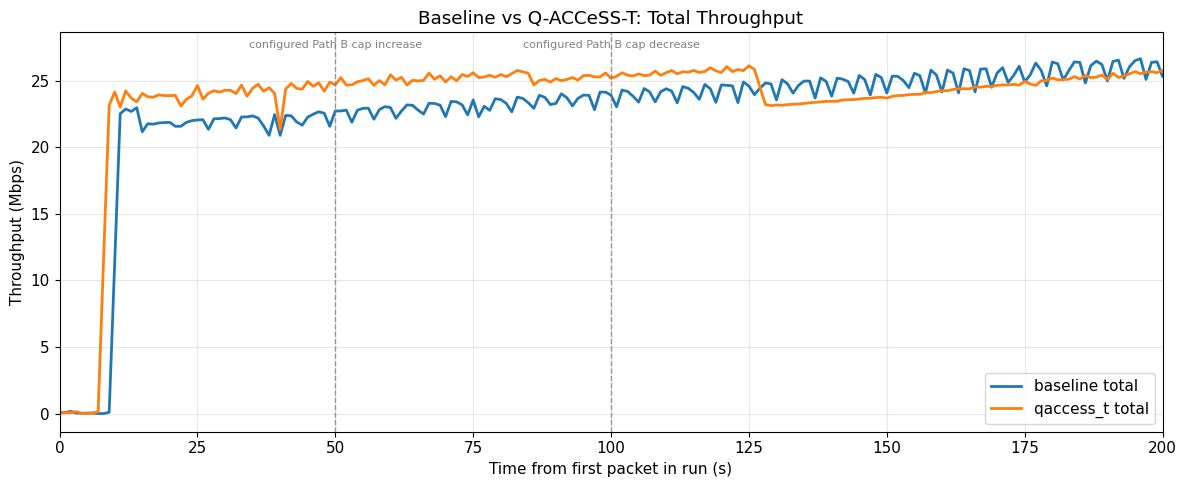

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_qaccess_t_20260527_011113/compare_phase1_high_bitrate/phase1_total_throughput.png


In [8]:
def add_profile_markers(ax):
    ax.axvline(50, linestyle="--", linewidth=1, color="gray", alpha=0.8)
    ax.axvline(100, linestyle="--", linewidth=1, color="gray", alpha=0.8)
    ax.text(50, ax.get_ylim()[1] * 0.98, "configured Path B cap increase", ha="center", va="top", fontsize=8, color="gray")
    ax.text(100, ax.get_ylim()[1] * 0.98, "configured Path B cap decrease", ha="center", va="top", fontsize=8, color="gray")


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_baseline["second"], df_baseline["total_mbps"], label="baseline total", linewidth=2)
ax.plot(df_qaccess["second"], df_qaccess["total_mbps"], label="qaccess_t total", linewidth=2)
add_profile_markers(ax)
ax.set_xlim(0, 200)
ax.set_xlabel("Time from first packet in run (s)")
ax.set_ylabel("Throughput (Mbps)")
ax.set_title("Baseline vs Q-ACCeSS-T: Total Throughput")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig_total = OUT_DIR / "phase1_total_throughput.png"
fig.savefig(fig_total, dpi=150)
plt.show()
print("Saved", fig_total)

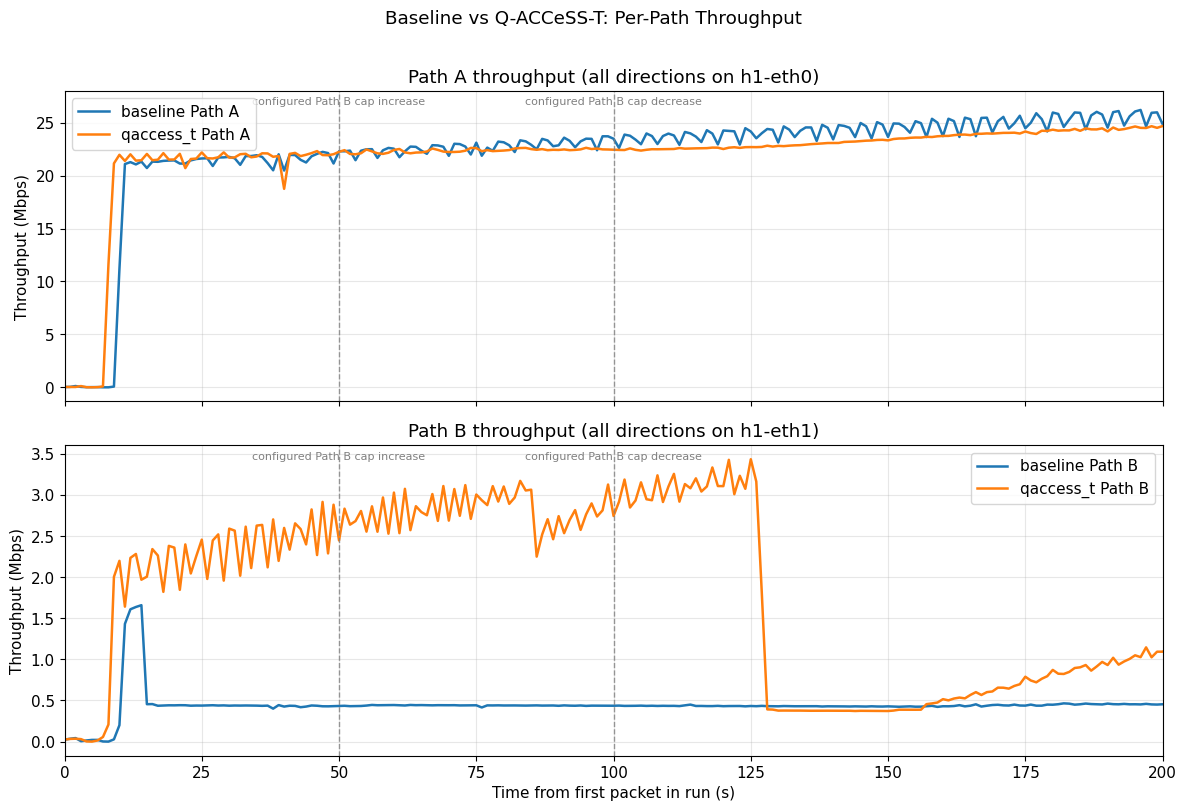

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_qaccess_t_20260527_011113/compare_phase1_high_bitrate/phase1_path_throughput.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df_baseline["second"], df_baseline["pathA_mbps"], label="baseline Path A", linewidth=1.8)
axes[0].plot(df_qaccess["second"], df_qaccess["pathA_mbps"], label="qaccess_t Path A", linewidth=1.8)
axes[0].set_ylabel("Throughput (Mbps)")
axes[0].set_title("Path A throughput (all directions on h1-eth0)")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)
add_profile_markers(axes[0])

axes[1].plot(df_baseline["second"], df_baseline["pathB_mbps"], label="baseline Path B", linewidth=1.8)
axes[1].plot(df_qaccess["second"], df_qaccess["pathB_mbps"], label="qaccess_t Path B", linewidth=1.8)
axes[1].set_xlabel("Time from first packet in run (s)")
axes[1].set_ylabel("Throughput (Mbps)")
axes[1].set_title("Path B throughput (all directions on h1-eth1)")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)
add_profile_markers(axes[1])
axes[1].set_xlim(0, 200)

fig.suptitle("Baseline vs Q-ACCeSS-T: Per-Path Throughput", y=1.01)
fig.tight_layout()
fig_paths = OUT_DIR / "phase1_path_throughput.png"
fig.savefig(fig_paths, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", fig_paths)

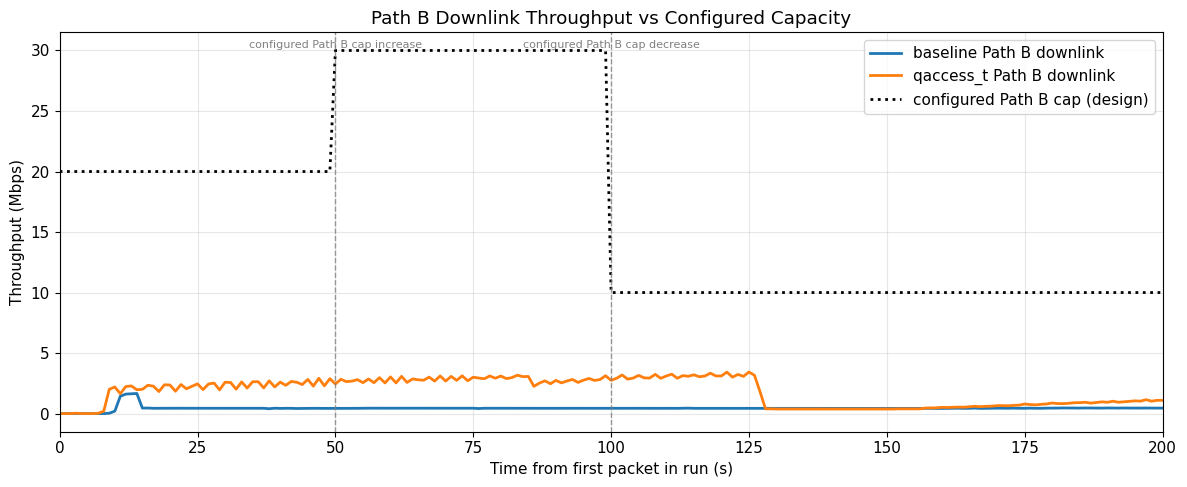

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_qaccess_t_20260527_011113/compare_phase1_high_bitrate/phase1_pathB_downlink_capacity_check.png


In [10]:
def cap_at_second(t: int) -> float:
    cap = PATH_B_CAP_STEPS[0][1]
    for at, bw in PATH_B_CAP_STEPS:
        if t >= at:
            cap = bw
    return float(cap)


cap_line = [cap_at_second(s) for s in range(0, 201)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_baseline_dn["second"], df_baseline_dn["pathB_downlink_mbps"], label="baseline Path B downlink", linewidth=2)
ax.plot(df_qaccess_dn["second"], df_qaccess_dn["pathB_downlink_mbps"], label="qaccess_t Path B downlink", linewidth=2)
ax.plot(range(0, 201), cap_line, label="configured Path B cap (design)", color="black", linestyle=":", linewidth=2)
add_profile_markers(ax)
ax.set_xlim(0, 200)
ax.set_xlabel("Time from first packet in run (s)")
ax.set_ylabel("Throughput (Mbps)")
ax.set_title("Path B Downlink Throughput vs Configured Capacity")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig_b = OUT_DIR / "phase1_pathB_downlink_capacity_check.png"
fig.savefig(fig_b, dpi=150)
plt.show()
print("Saved", fig_b)

In [11]:
ALERT_B = 10.5


def window_stats(df: pd.DataFrame, col: str, lo: int, hi: int) -> dict:
    w = df[(df["second"] >= lo) & (df["second"] < hi)]
    if w.empty:
        return {"mean": float("nan"), "max": float("nan")}
    return {"mean": float(w[col].mean()), "max": float(w[col].max())}


print("=== 1. Path B downlink after 100s (configured cap 10 Mbps) ===")
for lab, df in [("baseline", df_baseline_dn), ("qaccess_t", df_qaccess_dn)]:
    post = df[df["second"] >= 100]
    viol = post[post["pathB_downlink_mbps"] > ALERT_B]
    st = window_stats(df, "pathB_downlink_mbps", 100, 201)
    print(f"[{lab}] 100-200s Path B downlink: mean={st['mean']:.3f} max={st['max']:.3f} Mbps")
    print(f"  seconds > {ALERT_B} Mbps: {len(viol)}")

print()
print("=== 2. Total throughput: 50-100 vs 100-150 vs 100-200 ===")
for lab, df in [("baseline", df_baseline), ("qaccess_t", df_qaccess)]:
    w1 = mean_in_window(df, "total_mbps", 50, 100)
    w2 = mean_in_window(df, "total_mbps", 100, 150)
    w3 = mean_in_window(df, "total_mbps", 100, 201)
    print(f"[{lab}] 50-100: {w1:.3f}  100-150: {w2:.3f}  100-200: {w3:.3f} Mbps")

print()
print("=== 3. Path A share of total (all-direction) ===")
for lab, df in [("baseline", df_baseline), ("qaccess_t", df_qaccess)]:
    sub = df[(df["second"] >= 0) & (df["second"] < 200)]
    tot = sub["total_mbps"].mean()
    share = (sub["pathA_mbps"].mean() / tot * 100.0) if tot > 0 else float("nan")
    print(f"[{lab}] avg Path A / total ≈ {share:.1f}%")

print()
print("=== 4. Interpretation ===")
b_post = window_stats(df_baseline_dn, "pathB_downlink_mbps", 100, 201)
q_post = window_stats(df_qaccess_dn, "pathB_downlink_mbps", 100, 201)
if b_post["max"] <= ALERT_B and q_post["max"] <= ALERT_B:
    print("Path B downlink stays at or below ~10.5 Mbps after 100s — cap may be respected on Path B.")
else:
    print("Warning: Path B downlink exceeds configured post-100s capacity. Check tc profile, direction filter, or pcap alignment.")

b_50100 = mean_in_window(df_baseline, "total_mbps", 50, 100)
b_100200 = mean_in_window(df_baseline, "total_mbps", 100, 201)
if b_100200 >= b_50100 * 0.95:
    print("Total throughput does not clearly drop after 100s (expected if Path A dominates).")
    print("The Path B cap appears to apply on Path B downlink; interpret total together with per-path plots.")

full_imp = df_windows.loc[df_windows["window"] == "full", "improvement_pct"].iloc[0]
if full_imp == full_imp and full_imp > 0:
    print(f"Q-ACCeSS-T full-run total throughput improvement ≈ {full_imp:.2f}% (preliminary positive).")
elif full_imp == full_imp:
    print(f"Q-ACCeSS-T full-run total throughput improvement ≈ {full_imp:.2f}%.")

=== 1. Path B downlink after 100s (configured cap 10 Mbps) ===
[baseline] 100-200s Path B downlink: mean=0.438 max=0.465 Mbps
  seconds > 10.5 Mbps: 0
[qaccess_t] 100-200s Path B downlink: mean=1.293 max=3.434 Mbps
  seconds > 10.5 Mbps: 0

=== 2. Total throughput: 50-100 vs 100-150 vs 100-200 ===
[baseline] 50-100: 23.141  100-150: 24.380  100-200: 24.967 Mbps
[qaccess_t] 50-100: 25.170  100-150: 24.642  100-200: 24.720 Mbps

=== 3. Path A share of total (all-direction) ===
[baseline] avg Path A / total ≈ 98.1%
[qaccess_t] avg Path A / total ≈ 92.3%

=== 4. Interpretation ===
Path B downlink stays at or below ~10.5 Mbps after 100s — cap may be respected on Path B.
Total throughput does not clearly drop after 100s (expected if Path A dominates).
The Path B cap appears to apply on Path B downlink; interpret total together with per-path plots.
Q-ACCeSS-T full-run total throughput improvement ≈ 4.49% (preliminary positive).


## Interpretation notes (presentation)

- **Metric:** pcap-derived **throughput** on h1 per path (1 s bins, `frame.time_epoch` aligned across Path A and Path B within each run).
- **Input:** ~53 Mbps, ~200 s FLV stresses the source; observed wire throughput is still limited by links, scheduling, and caps.
- **Profile:** dynamic caps apply to **Path B server egress only** (`h2-eth1`). Path A stays at static ~20 Mbps TCLink.
- **Total vs Path B:** a visible **100 s drop on total** is **not required**; check **Path B downlink** vs configured 20 / 30 / 10 Mbps steps.
- **50 s / 100 s vertical lines:** configured profile times, not necessarily exact wall-clock alignment with pcap `t=0`.
- **baseline vs Q-ACCeSS-T:** higher **total** throughput in steady windows supports a preliminary Phase 1 gain; confirm on **Path A / Path B** breakdown and downlink view.
- **Next steps (out of scope here):** tighter tc/pcap alignment, optional Phase 2 runtime/worker analysis.